# 📘 Clase 3 · Notebook 5 — ARMA(p,q) y el procedimiento general de modelado

**Curso de Machine Learning · Time Series Forecasting**
Basado en *Time Series Forecasting in Python* (Marco Peixeiro), **Capítulo 6**.

| | |
|---|---|
| **Datos** | Serie **simulada** ARMA(1,1) y `bandwidth.csv` — uso horario de ancho de banda de un centro de datos (10 000 horas) |
| **Tiempo estimado en casa** | 45–60 min (las celdas de búsqueda y de pronóstico rodante con 10 000 puntos tardan varios minutos) |
| **¿Se vio en clase?** | ❌ No en detalle — se explica en diapositivas (Bloque 2). **Este notebook es para casa.** |

### 🎯 Al terminar este notebook podrás…
1. Reconocer un ARMA: **ni la ACF ni la PACF se cortan**.
2. Seleccionar el modelo con el criterio **AIC** mediante una búsqueda en malla.
3. Hacer **análisis de residuos**: Q-Q plot, `plot_diagnostics` y prueba de **Ljung-Box**.
4. Aplicar el **procedimiento general de modelado** a datos reales.

---

### ▶️ Cómo ejecutarlo

**En tu computador:** abre este notebook **desde su propia carpeta** (`CH06/`). Los datos se leen con la ruta relativa `../data/…`, así que si lo mueves de carpeta la lectura fallará.

**En Google Colab:** crea una celda al inicio y ejecuta:
```python
!git clone https://github.com/juandata-dev/TimeSeriesForecastingInPython.git
%cd TimeSeriesForecastingInPython/CH06
```

**Librerías:** `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scikit-learn`, `tqdm`.
Si te falta alguna: `pip install statsmodels scikit-learn tqdm`.

### 🗺️ Leyenda de las anotaciones
| Ícono | Significa |
|---|---|
| 🧭 | Qué hace la siguiente celda |
| 🔎 | Cómo leer el resultado que acabas de obtener |
| 💡 | Intuición o analogía para entender el concepto |
| ⚠️ | Cuidado: error común o trampa |
| 🛠️ | Cambio que hicimos al código original del libro para que funcione con versiones recientes de las librerías |
| 🤔 | Pregunta para pensar antes de seguir |

> Las celdas en inglés con `#` son los títulos originales del libro. Las anotaciones en español son de la clase.


## 0. Librerías y concepto
💡 **ARMA(p,q) = AR(p) + MA(q):** el presente depende de valores pasados **y** de sorpresas pasadas.

$$y_t = C + \sum_{i=1}^{p}\phi_i\,y_{t-i} + \varepsilon_t + \sum_{j=1}^{q}\theta_j\,\varepsilon_{t-j}$$

⚠️ El problema: con un ARMA, **ni la ACF ni la PACF se cortan** (ambas decaen o forman ondas), así que ya no sirven para leer *p* y *q*. Necesitamos otro método → **procedimiento general de modelado**:

1. ¿Estacionaria? Si no, transformar (diferenciar).
2. Listar valores posibles de *p* y *q*.
3. Ajustar **todas** las combinaciones ARMA(p,q).
4. Elegir la de **menor AIC**.
5. **Análisis de residuos** (Q-Q plot + Ljung-Box). Si son ruido blanco → listo para pronosticar. Si no → probar otros valores.

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from tqdm.auto import tqdm as tqdm_notebook  # 🛠️ tqdm.auto funciona en Jupyter, VS Code y Colab
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 6.3 Identifying a stationary ARMA process 

In [18]:
np.random.seed(42)

ar1 = np.array([1, -0.33])
ma1 = np.array([1, 0.9])

ARMA_1_1 = ArmaProcess(ar1, ma1).generate_sample(nsample=1000)

🧭 Simulamos un ARMA(1,1) con `ArmaProcess` y verificamos que sea estacionario.

In [19]:
ADF_result = adfuller(ARMA_1_1)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -6.4298786820426965
p-value: 1.707846668009642e-08


🔎 p-valor ≈ 0 → estacionaria. ✅

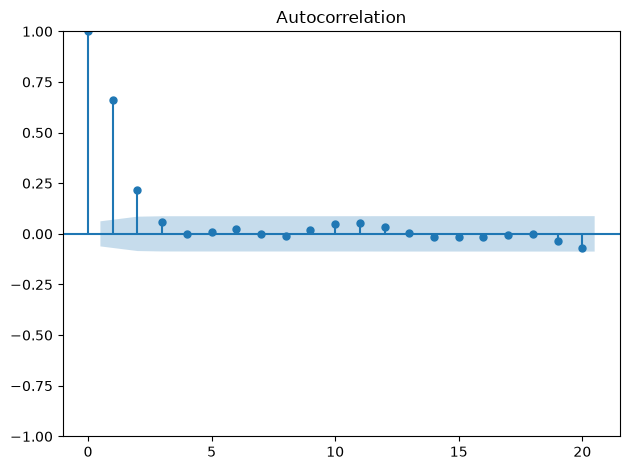

In [20]:
plot_acf(ARMA_1_1, lags=20);

plt.tight_layout()

plt.savefig('figures/CH06_F05_peixeiro.png', dpi=300)

🔎 La ACF decae con forma de onda: **no se corta**.

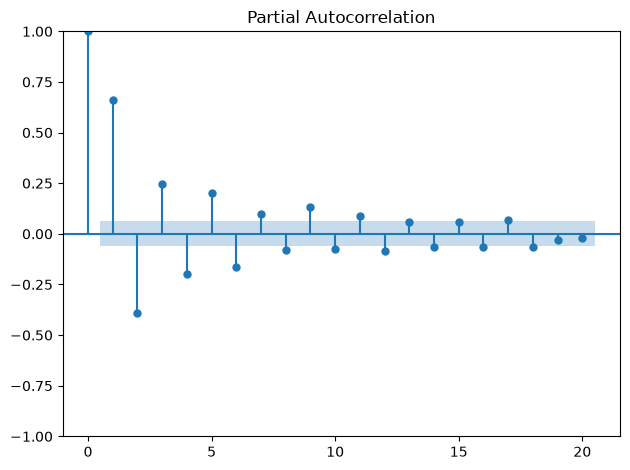

In [21]:
plot_pacf(ARMA_1_1, lags=20);

plt.tight_layout()

plt.savefig('figures/CH06_F06_peixeiro.png', dpi=300)

🔎 La PACF también decae: **no se corta**. → Ni MA puro ni AR puro: **ARMA**. Pero no podemos leer *p* y *q* en los gráficos.

### 6.4.1 Selecting the best model 

💡 **Criterio de información de Akaike (AIC)**

$$\text{AIC} = 2k - 2\ln(\hat{L})$$

*k* = número de parámetros; $\hat{L}$ = verosimilitud (qué tan bien se ajusta el modelo). **Menor AIC = mejor.**

Analogía: un examen que **premia acertar** (buen ajuste) pero **cobra una multa por cada fórmula extra** que llevas a la hoja (parámetros). Evita que elijamos modelos innecesariamente complejos (sobreajuste). Es la navaja de Ockham convertida en número.

⚠️ El AIC solo **compara** modelos entre sí sobre los mismos datos; su valor absoluto no significa nada.

🧭 Creamos la lista de todas las combinaciones (p, q) con p, q ∈ {0, 1, 2, 3}: 16 modelos.

In [22]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)

order_list = list(product(ps, qs))
print(order_list)

[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3)]


In [23]:
from typing import Union

def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [24]:
result_df = optimize_ARMA(ARMA_1_1, order_list)
result_df

100%|██████████| 16/16 [00:01<00:00,  9.50it/s]


,"(p,q)",AIC
0,"(1, 1)",2801.407785
1,"(2, 1)",2802.906070
2,"(1, 2)",2802.967762
3,"(0, 3)",2803.666793
4,"(1, 3)",2804.524027
5,"(3, 1)",2804.588567
6,"(2, 2)",2804.822282
7,"(3, 3)",2806.001496
8,"(2, 3)",2806.175380
9,"(3, 2)",2806.894930


🔎 La tabla está ordenada de menor a mayor AIC. El primer lugar es **(1,1)**: el procedimiento recupera el orden con el que simulamos la serie. ✅

### 6.4.3 Performing residuals analysis 

#### Qualitative analysis: studying the Q-Q plot

💡 **Q-Q plot (cuantil-cuantil).** Compara los cuantiles de nuestros datos con los de una distribución normal. Si los puntos caen sobre la **diagonal**, los datos son aproximadamente normales. Primero lo vemos con datos **no normales** (gamma) y luego con datos **normales**, para aprender a distinguirlos.

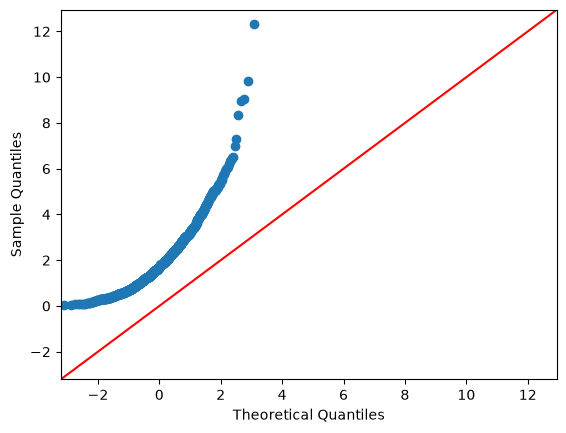

In [25]:
from statsmodels.graphics.gofplots import qqplot

gamma = np.random.default_rng().standard_gamma(shape=2, size=1000)

qqplot(gamma, line='45');

plt.savefig('figures/CH06_F11_peixeiro.png', dpi=300)

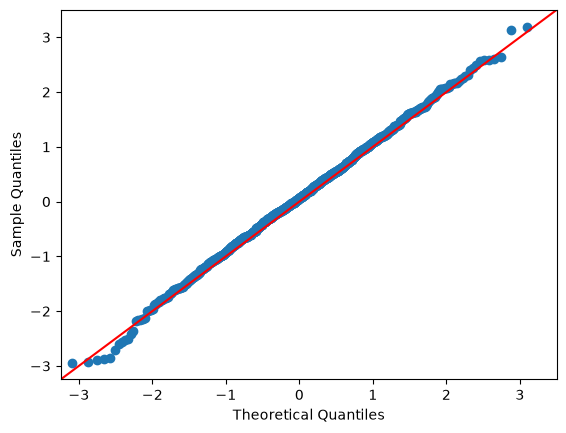

In [26]:
normal = np.random.normal(size=1000)

qqplot(normal, line='45');

plt.savefig('figures/CH06_F10_peixeiro.png', dpi=300)

### 6.4.4 Performing residuals analysis 

🧭 Ajustamos el ARMA(1,1) elegido por el AIC y extraemos sus **residuos** (real − ajustado).

In [31]:
model = SARIMAX(ARMA_1_1, order=(1,0,1), simple_differencing=False)
model_fit = model.fit(disp=False)
residuals = model_fit.resid

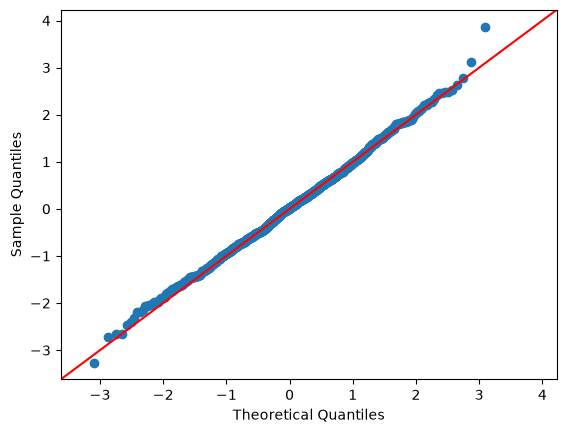

In [32]:
from statsmodels.graphics.gofplots import qqplot

qqplot(residuals, line='45');

plt.savefig('figures/CH06_F13_peixeiro.png', dpi=300)

🔎 Los residuos del ARMA(1,1) caen sobre la diagonal → aproximadamente normales. ✅

🔎 **Cómo leer los 4 paneles de `plot_diagnostics`** (queremos que los residuos parezcan **ruido blanco**, es decir, error puramente aleatorio):
1. **Residuos estandarizados (arriba izq.):** deben oscilar alrededor de 0, sin tendencia y con varianza más o menos constante.
2. **Histograma + densidad (arriba der.):** debe parecerse a la campana normal (línea N(0,1)).
3. **Q-Q plot (abajo izq.):** los puntos deben caer sobre la línea roja diagonal. Si se curvan en los extremos, los residuos no son normales.
4. **Correlograma / ACF (abajo der.):** ninguna barra (salvo la del rezago 0) debe salir de la zona azul.

💡 Analogía: si el modelo es bueno, lo que “sobra” (los residuos) debe ser como el ruido de estática de un radio: no queda ninguna melodía escondida que el modelo no haya escuchado.

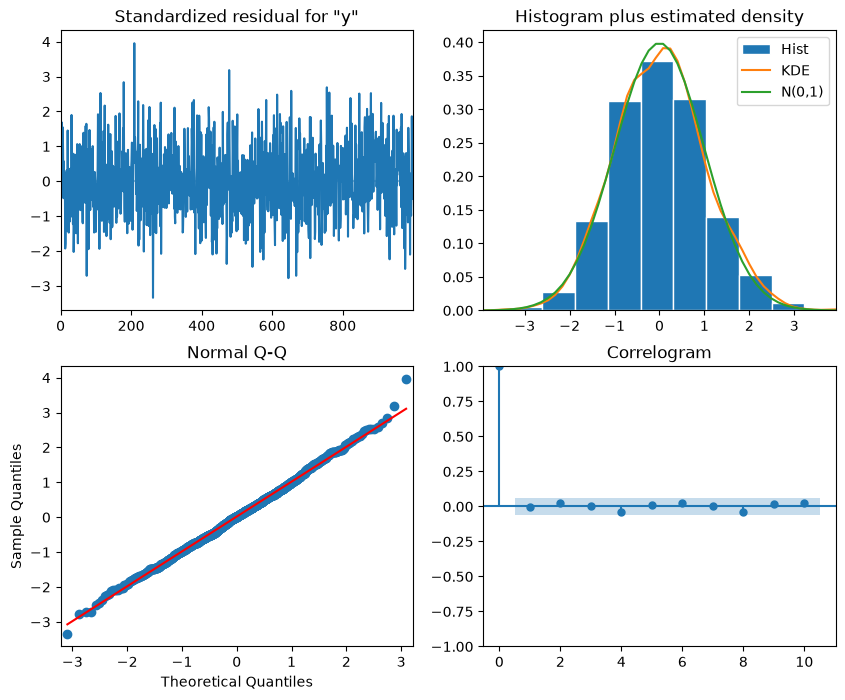

In [33]:
model_fit.plot_diagnostics(figsize=(10, 8));

plt.savefig('figures/CH06_F14_peixeiro.png', dpi=300)

🛠️ **Pprueba de Ljung-Box.** En versiones recientes de `statsmodels`, `acorr_ljungbox` devuelve una **tabla** (DataFrame) y no dos listas. El código original (`lbvalue, pvalue = acorr_ljungbox(...)`) ya no falla, pero imprime solo el texto `lb_pvalue` en lugar de los números: un error silencioso. Aquí guardamos la tabla completa y mostramos la columna de p-valores.

In [35]:
# 🛠️ Versión actualizada (statsmodels >= 0.13 devuelve un DataFrame)
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_df = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1), return_df=True)

print(lb_df['lb_pvalue'])
print('\n¿Todos los p-valores > 0.05?', (lb_df['lb_pvalue'] > 0.05).all())

1     0.860897
2     0.767966
3     0.909817
4     0.721089
5     0.810385
6     0.821750
7     0.894063
8     0.817501
9     0.852419
10    0.874093
Name: lb_pvalue, dtype: float64

¿Todos los p-valores > 0.05? True


🔎 **Cómo leer Ljung-Box.** Hipótesis nula (H0): *los residuos NO están correlacionados* (son ruido blanco).
- **p-valor > 0.05 en todos los rezagos** → no rechazamos H0 → los residuos parecen ruido blanco → ✅ el modelo capturó la información útil.
- p-valor < 0.05 en algún rezago → queda estructura sin explicar → conviene probar otro orden del modelo.

⚠️ Ojo: aquí **queremos p-valores ALTOS**, al revés que en la prueba ADF (donde queremos p-valores bajos para declarar estacionariedad).

## 6.5 Applying the general modeling procedure 

## Aplicación a datos reales: ancho de banda horario
🧭 Seguimos **exactamente** los pasos del procedimiento general.

In [37]:
import pandas as pd

df = pd.read_csv('../data/bandwidth.csv')

df.head()

,hourly_bandwidth
0,1000.496714
1,1000.969408
2,1002.046019
3,1004.702118
4,1007.447816


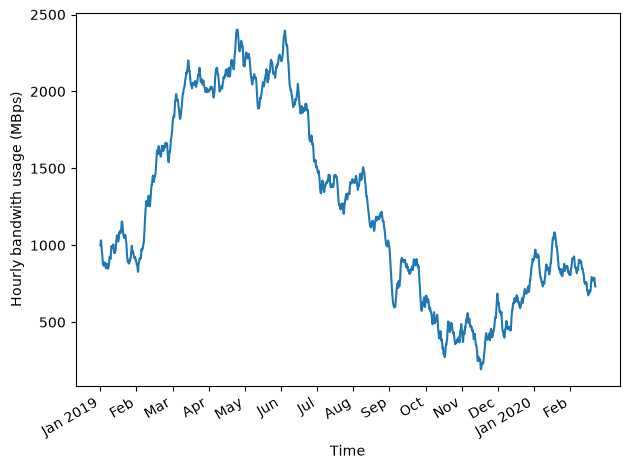

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(df['hourly_bandwidth'])
ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage (MBps)')

plt.xticks(
    np.arange(0, 10000, 730), 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH06_F02_peixeiro.png', dpi=300)

In [39]:
ADF_result = adfuller(df['hourly_bandwidth'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -0.8714653199451994
p-value: 0.7972240255014788


In [40]:
bandwidth_diff = np.diff(df.hourly_bandwidth, n=1)

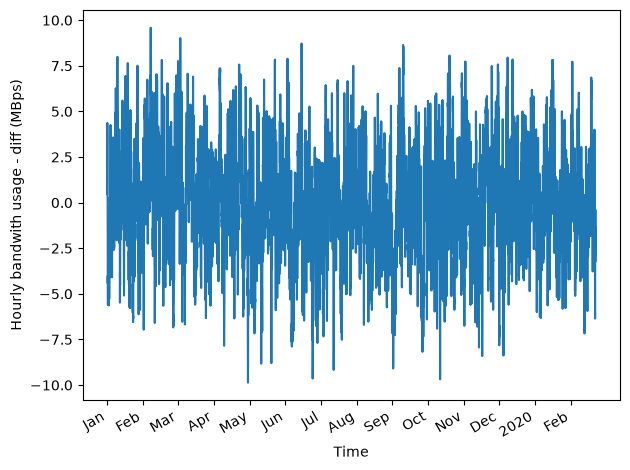

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(bandwidth_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage - diff (MBps)')

plt.xticks(
    np.arange(0, 10000, 730), 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

# plt.savefig('figures/CH06_F_peixeiro.png', dpi=300)

In [42]:
ADF_result = adfuller(bandwidth_diff)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -20.694853863789028
p-value: 0.0


🧭 ACF y PACF de la serie diferenciada: ¿se corta alguna?

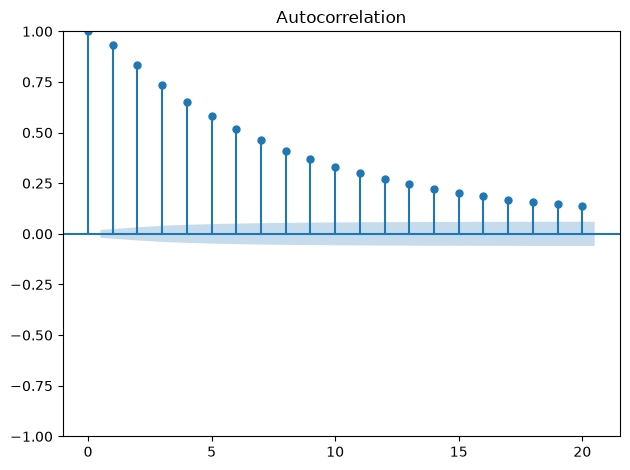

In [43]:
plot_acf(bandwidth_diff, lags=20);

plt.tight_layout()

# plt.savefig('figures/CH06_F_peixeiro.png', dpi=300)

🔎 Ninguno de los dos gráficos se corta claramente → usamos el procedimiento general.

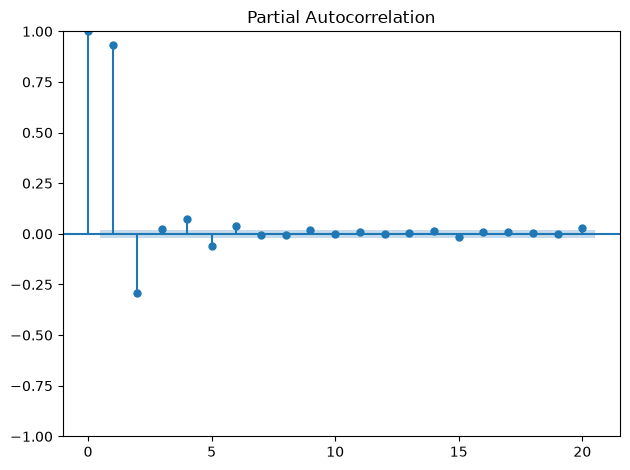

In [44]:
plot_pacf(bandwidth_diff, lags=20);

plt.tight_layout()

# plt.savefig('figures/CH06_F_peixeiro.png', dpi=300)

🧭 Test = **las últimas 168 horas** (7 días × 24 h = una semana).

In [45]:
df_diff = pd.DataFrame({'bandwidth_diff': bandwidth_diff})

train = df_diff[:-168]
test = df_diff[-168:]

print(len(train))
print(len(test))

9831
168


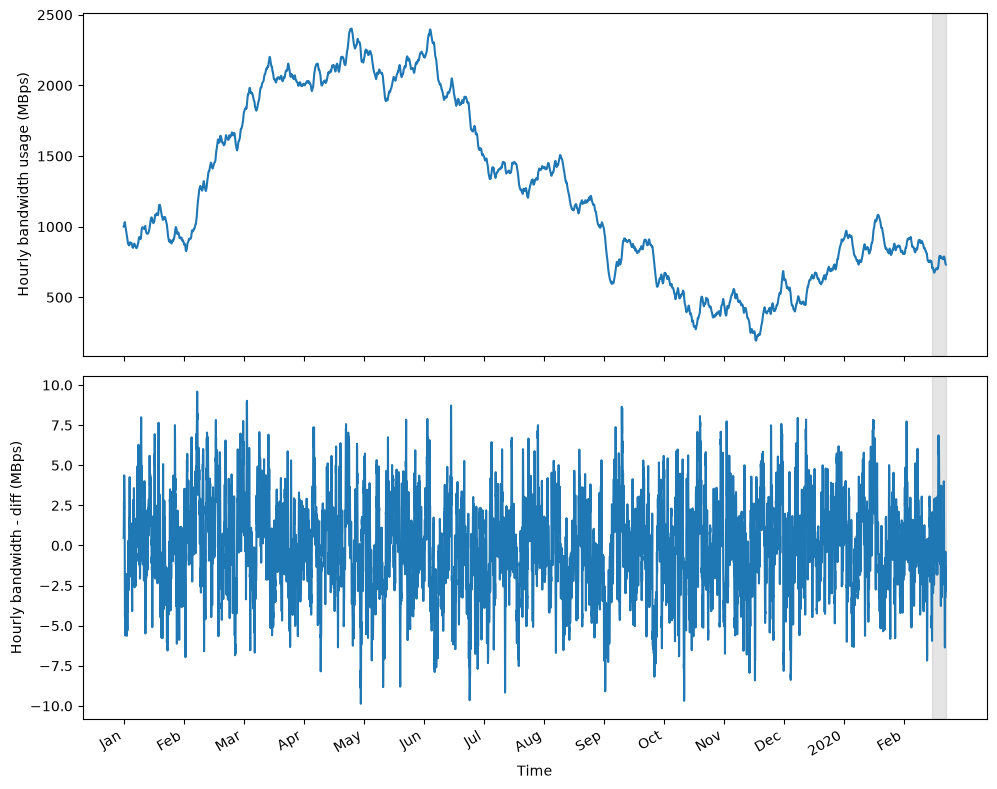

In [46]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 8))

ax1.plot(df['hourly_bandwidth'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Hourly bandwidth usage (MBps)')
ax1.axvspan(9831, 10000, color='#808080', alpha=0.2)

ax2.plot(df_diff['bandwidth_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Hourly bandwidth - diff (MBps)')
ax2.axvspan(9830, 9999, color='#808080', alpha=0.2)

plt.xticks(
    np.arange(0, 10000, 730), 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH06_F17_peixeiro.png', dpi=300)

In [47]:
from typing import Union

def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [48]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)

order_list = list(product(ps, qs))

⏱️ **Esta celda es lenta.** La búsqueda en malla (*grid search*) ajusta un modelo por **cada** combinación de órdenes. Dejamos una bandera `EJECUTAR_BUSQUEDA = False` para que puedas seguir el notebook sin esperar: en ese caso se muestra el resultado ya conocido. Cuando tengas tiempo, cámbiala a `True` y compruébalo tú mismo.

In [ ]:
EJECUTAR_BUSQUEDA = False   # ⏱️ Cambia a True para correr las 16 combinaciones (tarda varios minutos)

if EJECUTAR_BUSQUEDA:
    result_df = optimize_ARMA(train['bandwidth_diff'], order_list)
else:
    print('Búsqueda omitida. Resultado conocido (libro, sección 6.5): el menor AIC corresponde a (p,q) = (2,2).')
    result_df = pd.DataFrame({'(p,q)': [(2, 2)], 'AIC': ['ver valore del libro']})
result_df

100%|██████████| 16/16 [00:07<00:00,  2.18it/s]


,"(p,q)",AIC
0,"(3, 2)",27991.063879
1,"(2, 3)",27991.287509
2,"(2, 2)",27991.603598
3,"(3, 3)",27993.416924
4,"(1, 3)",28003.349550
5,"(1, 2)",28051.351401
6,"(3, 1)",28071.155496
7,"(3, 0)",28095.618186
8,"(2, 1)",28097.250766
9,"(2, 0)",28098.407664


In [52]:
model = SARIMAX(train['bandwidth_diff'], order=(2,0,2), simple_differencing=False)
model_fit = model.fit(disp=False)
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         bandwidth_diff   No. Observations:                 9831
Model:               SARIMAX(2, 0, 2)   Log Likelihood              -13990.802
Date:                Fri, 02 Oct 2026   AIC                          27991.604
Time:                        14:31:05   BIC                          28027.570
Sample:                             0   HQIC                         28003.788
                               - 9831                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3486      0.052      6.765      0.000       0.248       0.450
ar.L2          0.4743      0.047     10.000      0.000       0.381       0.567
ma.L1          0.8667      0.050     17.249      0.0

🔎 **Cómo leer los 4 paneles de `plot_diagnostics`** (queremos que los residuos parezcan **ruido blanco**, es decir, error puramente aleatorio):
1. **Residuos estandarizados (arriba izq.):** deben oscilar alrededor de 0, sin tendencia y con varianza más o menos constante.
2. **Histograma + densidad (arriba der.):** debe parecerse a la campana normal (línea N(0,1)).
3. **Q-Q plot (abajo izq.):** los puntos deben caer sobre la línea roja diagonal. Si se curvan en los extremos, los residuos no son normales.
4. **Correlograma / ACF (abajo der.):** ninguna barra (salvo la del rezago 0) debe salir de la zona azul.

💡 Analogía: si el modelo es bueno, lo que “sobra” (los residuos) debe ser como el ruido de estática de un radio: no queda ninguna melodía escondida que el modelo no haya escuchado.

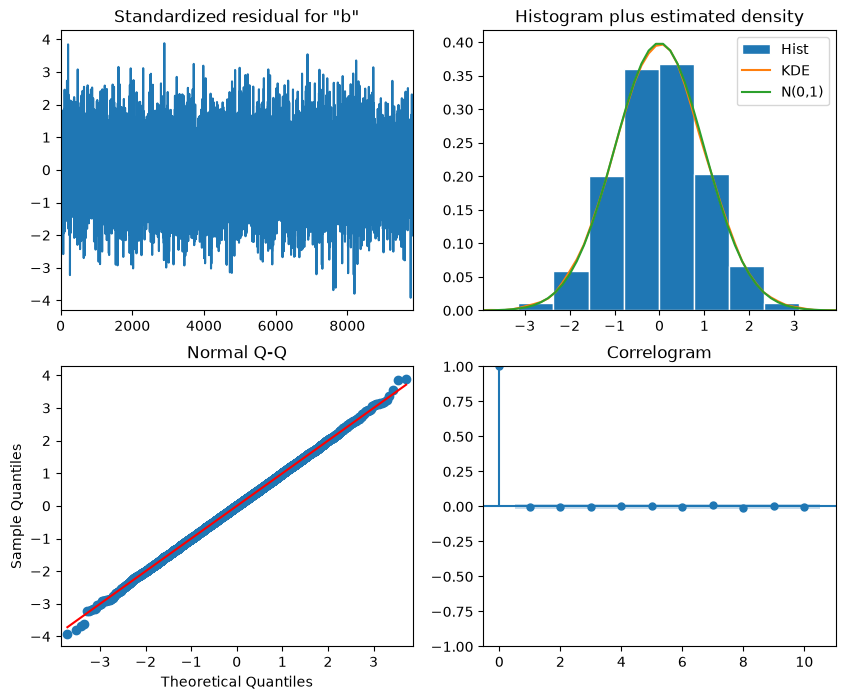

In [53]:
model_fit.plot_diagnostics(figsize=(10, 8));

plt.savefig('figures/CH06_F19_peixeiro.png', dpi=300)

🛠️ **Prueba de Ljung-Box.** En versiones recientes de `statsmodels`, `acorr_ljungbox` devuelve una **tabla** (DataFrame) y no dos listas. El código original (`lbvalue, pvalue = acorr_ljungbox(...)`) ya no falla, pero imprime solo el texto `lb_pvalue` en lugar de los números: un error silencioso. Aquí guardamos la tabla completa y mostramos la columna de p-valores.

In [54]:
residuals = model_fit.resid

# 🛠️ Versión actualizada (statsmodels >= 0.13 devuelve un DataFrame)
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_df = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1), return_df=True)

print(lb_df['lb_pvalue'])
print('\n¿Todos los p-valores > 0.05?', (lb_df['lb_pvalue'] > 0.05).all())

1     0.837257
2     0.811247
3     0.914416
4     0.931545
5     0.973678
6     0.981019
7     0.952607
8     0.919067
9     0.953615
10    0.964015
Name: lb_pvalue, dtype: float64

¿Todos los p-valores > 0.05? True


🔎 **Cómo leer Ljung-Box.** Hipótesis nula (H0): *los residuos NO están correlacionados* (son ruido blanco).
- **p-valor > 0.05 en todos los rezagos** → no rechazamos H0 → los residuos parecen ruido blanco → ✅ el modelo capturó la información útil.
- p-valor < 0.05 en algún rezago → queda estructura sin explicar → conviene probar otro orden del modelo.

⚠️ Ojo: aquí **queremos p-valores ALTOS**, al revés que en la prueba ADF (donde queremos p-valores bajos para declarar estacionariedad).

## 6.6 Forecasting bandwidth usage

💡 **Pronóstico rodante (*rolling forecast*).** En vez de pronosticar los 168 puntos del test de una sola vez, avanzamos de a `WINDOW` pasos:
1. Entrenamos con todo lo conocido hasta el momento *i*.
2. Pronosticamos los siguientes `WINDOW` pasos.
3. “Llegan” los datos reales de esos pasos, los agregamos al entrenamiento y repetimos.

Analogía: el pronóstico del clima se actualiza cada día con la observación nueva; nadie pronostica todo el mes de una sola vez.

⏱️ Con ~9 800 puntos, cada ajuste tarda; la celda de pronóstico rodante puede demorar **varios minutos**.

🧭 La función `rolling_forecast` implementa tres métodos para compararlos en igualdad de condiciones: `mean` (media), `last` (último valor) y el modelo estadístico. Dentro del modelo: `get_prediction(0, i + window - 1)` genera predicciones hasta el final de la ventana y `.iloc[-window:]` se queda solo con las **fuera de muestra** (las del futuro).

In [55]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'mean':
        pred_mean = []
        
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'ARMA':
        pred_ARMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(2,0,2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)
            
        return pred_ARMA

In [56]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_ARMA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'ARMA')

test.loc[:, 'pred_mean'] = pred_mean
test.loc[:, 'pred_last_value'] = pred_last_value
test.loc[:, 'pred_ARMA'] = pred_ARMA

test.head()

,bandwidth_diff,pred_mean,pred_last_value,pred_ARMA
9831,-5.943995,-0.028214,-5.791207,-5.460661
9832,-5.865194,-0.028214,-5.791207,-4.890626
9833,-3.197066,-0.029410,-5.865194,-5.335905
9834,-1.090197,-0.029410,-5.865194,-4.751731
9835,0.665291,-0.029840,-1.090197,-0.375596


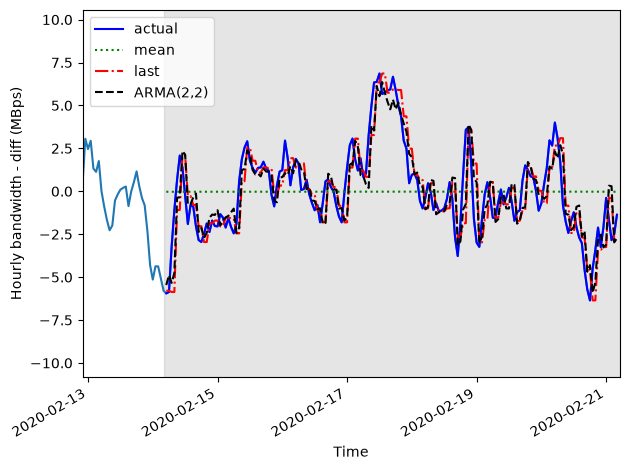

In [57]:
fig, ax = plt.subplots()

ax.plot(df_diff['bandwidth_diff'])
ax.plot(test['bandwidth_diff'], 'b-', label='actual')
ax.plot(test['pred_mean'], 'g:', label='mean')
ax.plot(test['pred_last_value'], 'r-.', label='last')
ax.plot(test['pred_ARMA'], 'k--', label='ARMA(2,2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwidth - diff (MBps)')

ax.axvspan(9830, 9999, color='#808080', alpha=0.2)

ax.set_xlim(9800, 9999)

plt.xticks(
    [9802, 9850, 9898, 9946, 9994],
    ['2020-02-13', '2020-02-15', '2020-02-17', '2020-02-19', '2020-02-21'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH06_F20_peixeiro.png', dpi=300)

In [58]:
mse_mean = mean_squared_error(test['bandwidth_diff'], test['pred_mean'])
mse_last = mean_squared_error(test['bandwidth_diff'], test['pred_last_value'])
mse_ARMA = mean_squared_error(test['bandwidth_diff'], test['pred_ARMA'])

print(mse_mean, mse_last, mse_ARMA)

6.306526957989325 2.2297582947733656 1.7690462115044372


🔎 MSE: media ≈ 6.31, último valor ≈ 2.23, **ARMA(2,2) ≈ 1.77**. El ARMA gana.

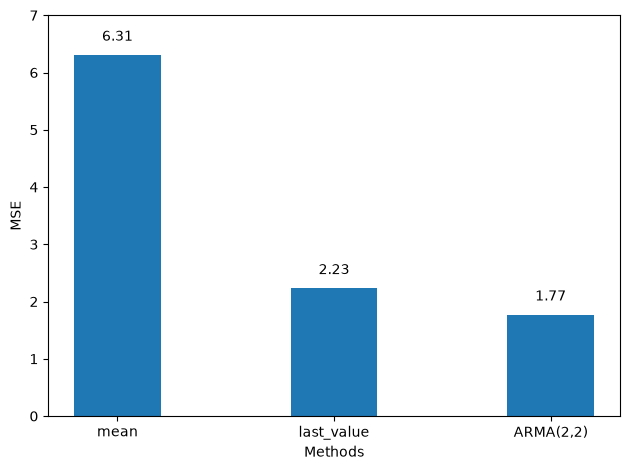

In [59]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'ARMA(2,2)']
y = [mse_mean, mse_last, mse_ARMA] 

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 7)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

# plt.savefig('figures/CH06_F_peixeiro.png', dpi=300)

💡 **Volver a la escala original (invertir la diferenciación).** El modelo pronosticó **cambios** (serie diferenciada), pero al negocio le interesan **niveles** (ventas reales). Como diferenciar es restar, deshacerlo es **sumar acumuladamente**: valor inicial + suma acumulada de los cambios pronosticados (`cumsum`).

🛠️ **Cambio respecto al libro.** El original usaba asignación encadenada (`df['col'][a:] = ...`). Desde pandas 2.x/3.x (*Copy-on-Write*) eso **ya no modifica** `df` y la columna quedaba vacía (la siguiente celda fallaba con `Input contains NaN`). Usamos `df.loc[...]`, que es la forma correcta.

In [60]:
df['pred_bandwidth'] = np.nan

# 🛠️ .loc en lugar de asignación encadenada (compatible con pandas 2.x / 3.x)
df.loc[9832:, 'pred_bandwidth'] = df['hourly_bandwidth'].iloc[9832] + test['pred_ARMA'].cumsum().values

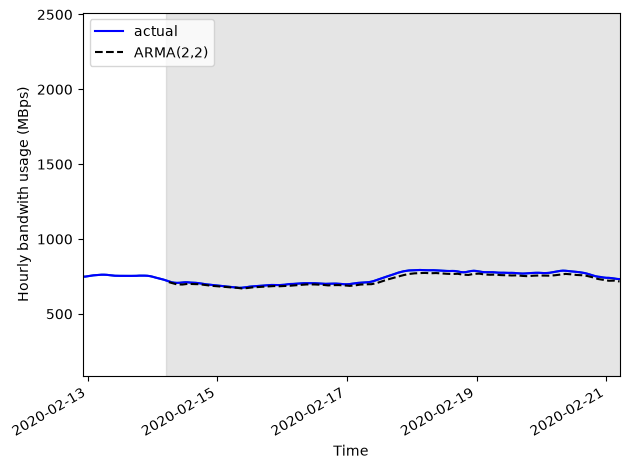

In [61]:
fig, ax = plt.subplots()

ax.plot(df['hourly_bandwidth'])
ax.plot(df['hourly_bandwidth'], 'b-', label='actual')
ax.plot(df['pred_bandwidth'], 'k--', label='ARMA(2,2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage (MBps)')

ax.axvspan(9831, 10000, color='#808080', alpha=0.2)

ax.set_xlim(9800, 9999)

plt.xticks(
    [9802, 9850, 9898, 9946, 9994],
    ['2020-02-13', '2020-02-15', '2020-02-17', '2020-02-19', '2020-02-21'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH06_F21_peixeiro.png', dpi=300)

In [62]:
mae_ARMA_undiff = mean_absolute_error(df['hourly_bandwidth'][9832:], df['pred_bandwidth'][9832:])

print(mae_ARMA_undiff)

14.000362773731766


🔎 MAE ≈ 14 MBps en la escala original del ancho de banda.

---
## ✅ Resumen: el procedimiento general de modelado
```
Datos → ¿estacionaria? ──no──► diferenciar ──┐
            │ sí                              │
            ▼◄────────────────────────────────┘
   Listar (p, q) → ajustar todos → elegir menor AIC
            ▼
   Residuos: ¿Q-Q recto? ¿Ljung-Box p > 0.05?
        sí → pronosticar      no → probar otros (p, q)
```
Este procedimiento **reemplaza** la lectura de ACF/PACF y es el mismo que usaremos para ARIMA, SARIMA y SARIMAX.

### 🏠 Ejercicios para casa
`CH06_exercises_solution.ipynb`: simula un ARMA(2,2) y aplica todo el procedimiento.

### 🧠 Autoevaluación
- ¿Por qué el AIC penaliza el número de parámetros?
- En Ljung-Box, ¿queremos p-valores altos o bajos? ¿Y en ADF?
